# 第010讲 矩阵与线性变换

从单向量到批量样本，用手算、循环、矩阵、几何图互相核验。全部数据与坐标为课程合成且无量纲，没有模型拟合或性能评估。

请按顺序执行。最后重启内核并Run All。界面与Anaconda安装未在构建环境测试；本包已有新进程真实ipykernel进程内执行输出。

## 1 环境与输入

应存在两个原始文件。版本输出只显示版本号，不显示个人目录。NumPy完成计算，Matplotlib画图。

In [1]:
from pathlib import Path
import sys, json, csv, os
from io import BytesIO
os.environ.setdefault("MPLCONFIGDIR", str(Path(".mpl_cache").resolve()))
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT = Path.cwd()
DATA = ROOT / "data"
assert (DATA / "samples.csv").is_file()
assert (DATA / "matrices.json").is_file()
print({"python": sys.version.split()[0], "numpy": np.__version__, "matplotlib": matplotlib.__version__})
print("两个原始数据文件存在")
def show_figure(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

{'python': '3.12.14', 'numpy': '2.3.5', 'matplotlib': '3.10.8'}
两个原始数据文件存在


## 2 读入样本与矩阵并命名轴

X是4条样本×3个特征，A是2条输出规则×3个输入坐标，B是3×2。读CSV时明确固定特征顺序x1、x2、x3。

In [2]:
with (DATA / "samples.csv").open(encoding="utf-8", newline="") as f:
    records = list(csv.DictReader(f))
ids = [r["sample_id"] for r in records]
X = np.array([[float(r[name]) for name in ["x1", "x2", "x3"]] for r in records])
config = json.loads((DATA / "matrices.json").read_text(encoding="utf-8"))
A = np.array(config["A_rect"], dtype=float)
B = np.array(config["B_rect"], dtype=float)
H = np.array(config["shear"], dtype=float)
D = np.array(config["stretch"], dtype=float)
for name, arr in [("X",X),("A",A),("B",B)]:
    print(name, "shape =", arr.shape)
    print(arr)
assert X.shape == (4,3) and A.shape == (2,3) and B.shape == (3,2)
print("数学a23对应A[1,2]：", A[1,2])

X shape = (4, 3)
[[ 1.  2.  0.]
 [ 0.  1.  3.]
 [ 2. -1.  1.]
 [ 3.  0.  2.]]
A shape = (2, 3)
[[ 1.  2. -1.]
 [ 0. -1.  3.]]
B shape = (3, 2)
[[ 2.  1.]
 [ 1.  0.]
 [-1.  2.]]
数学a23对应A[1,2]： 3.0


## 3 一个输出格子先手算

A第1行与B第1列相乘求和：1×2+2×1+(-1)×(-1)=5。不是相同位置的逐元素乘法最终结果。

In [3]:
row = A[0,:]
column = B[:,0]
products = row * column
print("对应乘积", products)
print("求和", products.sum())
assert products.sum() == 5
print("AB完整结果")
print(A @ B)
assert np.array_equal(A @ B, [[5,-1],[-4,6]])

对应乘积 [2. 2. 1.]
求和 5.0
AB完整结果
[[ 5. -1.]
 [-4.  6.]]


## 4 用三个循环独立实现矩阵乘法

外层i选择输出行，j选择输出列，ell沿共同维数累加。循环内不用@，所以能与向量化实现独立比对。

In [4]:
def multiply_by_loops(left, right):
    left = np.asarray(left, dtype=float)
    right = np.asarray(right, dtype=float)
    if left.ndim != 2 or right.ndim != 2:
        raise ValueError("输入必须都是二维")
    m, d = left.shape
    if d != right.shape[0]:
        raise ValueError("共同维数不一致")
    k = right.shape[1]
    output = np.zeros((m,k))
    for i in range(m):
        for j in range(k):
            total = 0.0
            for ell in range(d):
                total += left[i,ell] * right[ell,j]
            output[i,j] = total
    return output
loop_AB = multiply_by_loops(A,B)
print(loop_AB)
assert np.allclose(loop_AB, A @ B)
assert np.allclose(multiply_by_loops(B,A), B @ A)
print("BA形状与结果", (B @ A).shape)
print(B @ A)

[[ 5. -1.]
 [-4.  6.]]
BA形状与结果 (3, 3)
[[ 2.  3.  1.]
 [ 1.  2. -1.]
 [-1. -4.  7.]]


## 5 逐元素乘法与次序

预期H*D、H@D、D@H右上角分别为0、1、2。相同尺寸不保证相同含义。

In [5]:
print("逐元素 H*D\n", H*D)
print("矩阵 H@D\n", H@D)
print("矩阵 D@H\n", D@H)
assert (H*D)[0,1] == 0
assert (H@D)[0,1] == 1
assert (D@H)[0,1] == 2
assert not np.allclose(H@D,D@H)

逐元素 H*D
 [[2. 0.]
 [0. 1.]]
矩阵 H@D
 [[2. 1.]
 [0. 1.]]
矩阵 D@H
 [[2. 2.]
 [0. 1.]]


## 6 列向量规则与两种计算路线

A把三个输入坐标映成两个输出。对x=(2,-1,1)，按行与按列都应得到(-1,4)。

In [6]:
x = np.array([2.,-1.,1.])
by_rows = np.array([sum(A[i,j]*x[j] for j in range(3)) for i in range(2)])
by_columns = x[0]*A[:,0] + x[1]*A[:,1] + x[2]*A[:,2]
print("按行",by_rows,"按列",by_columns,"@",A@x)
assert np.array_equal(A@x,[-1,4])
assert np.array_equal(by_rows,by_columns)
assert np.array_equal(A@np.zeros(3),np.zeros(2))

按行 [-1.  4.] 按列 [-1.  4.] @ [-1.  4.]


## 7 矩阵列是单位输入的像

M的列依次是M e1与M e2。输入(1,2)的像应为(4,3)。

In [7]:
M = np.array(config["column_demo"], dtype=float)
e1, e2 = np.array([1.,0.]), np.array([0.,1.])
print("M e1", M@e1)
print("M e2", M@e2)
print("M(1,2)", M@np.array([1.,2.]))
assert np.array_equal(M@e1,M[:,0])
assert np.array_equal(M@e2,M[:,1])
assert np.array_equal(M@(e1+2*e2),M@e1+2*(M@e2))

M e1 [2. 1.]
M e2 [1. 1.]
M(1,2) [4. 3.]


## 8 网格绘图函数

每条网格线由一批行坐标表示，所以转换写points @ transform.T。英文标签避免本机缺中文字体；灰色输入、蓝色输出、equal坐标比例。

In [8]:
def draw_grid(ax, transform, title, limit=4.5):
    values = np.linspace(-2,2,61)
    for fixed in np.arange(-2,2.01,.5):
        lines = [np.column_stack([values,np.full_like(values,fixed)]),
                 np.column_stack([np.full_like(values,fixed),values])]
        for points in lines:
            mapped_points = points @ transform.T
            ax.plot(points[:,0],points[:,1],color="#AAB3BD",lw=.6,alpha=.5)
            ax.plot(mapped_points[:,0],mapped_points[:,1],color="#2667A8",lw=1)
    ax.set(xlim=(-limit,limit),ylim=(-limit,limit),xlabel="coordinate 1 (dimensionless)",
           ylabel="coordinate 2 (dimensionless)",title=title)
    ax.set_aspect("equal")
    ax.axhline(0,color="black",lw=.5)
    ax.axvline(0,color="black",lw=.5)
print("网格函数已定义：行样本使用transform.T")

网格函数已定义：行样本使用transform.T


## 9 缩放与剪切

缩放改变一般长度，剪切让高度参与横坐标。不要从“线性”推断“等距”。

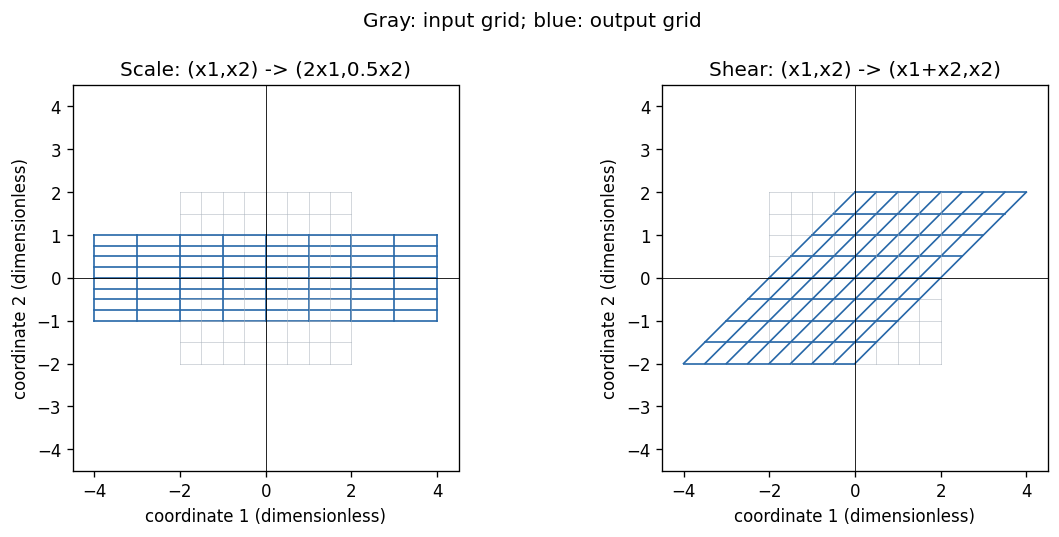

In [9]:
S = np.array(config["scale"],dtype=float)
fig, axes = plt.subplots(1,2,figsize=(10,4.5))
draw_grid(axes[0],S,"Scale: (x1,x2) -> (2x1,0.5x2)")
draw_grid(axes[1],H,"Shear: (x1,x2) -> (x1+x2,x2)")
fig.suptitle("Gray: input grid; blue: output grid")
fig.tight_layout()
show_figure(fig)
assert not np.isclose(np.linalg.norm(S@e1),np.linalg.norm(e1))

## 10 先用单位圆规定角度

45度=π/4弧度。NumPy三角函数接收弧度。0度、90度的单位方向提供独立已知答案。

In [10]:
theta = np.deg2rad(45)
print("45度的弧度",theta,"π/4",np.pi/4)
print("cos与sin",np.cos(theta),np.sin(theta))
assert np.isclose(theta,np.pi/4)
assert np.allclose([np.cos(theta),np.sin(theta)],[np.sqrt(.5),np.sqrt(.5)])
def make_rotation(theta_radians):
    c,s = np.cos(theta_radians),np.sin(theta_radians)
    return np.array([[c,-s],[s,c]])
R = make_rotation(theta)
print(R)
assert np.allclose(make_rotation(np.deg2rad(90))@e1,e2,atol=1e-12)

45度的弧度 0.7853981633974483 π/4 0.7853981633974483
cos与sin 0.7071067811865476 0.7071067811865475
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


## 11 旋转与压扁

压扁把不同高度合并到同一输出。旋转网格的边长与角度保持，后面用R转置R核验。

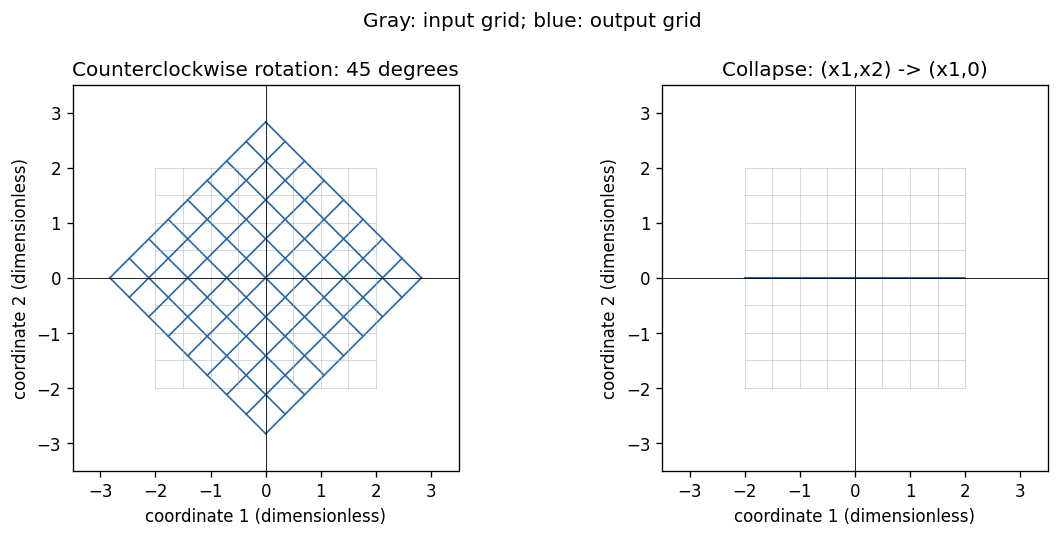

不同输入的相同输出 [1. 0.] [1. 0.]


In [11]:
P = np.array(config["collapse"],dtype=float)
fig, axes = plt.subplots(1,2,figsize=(10,4.5))
draw_grid(axes[0],R,"Counterclockwise rotation: 45 degrees",3.5)
draw_grid(axes[1],P,"Collapse: (x1,x2) -> (x1,0)",3.5)
fig.suptitle("Gray: input grid; blue: output grid")
fig.tight_layout()
show_figure(fig)
print("不同输入的相同输出", P@np.array([1,2]), P@np.array([1,-1]))
assert np.array_equal(P@np.array([1,2]),P@np.array([1,-1]))

## 12 复合顺序与结合律

离x最近的矩阵先作用。结合律只改变括号，不交换矩阵。

In [12]:
x2 = np.array([1.,1.])
print("先D后H",H@(D@x2))
print("先H后D",D@(H@x2))
assert np.array_equal(H@(D@x2),[3,1])
assert np.array_equal(D@(H@x2),[4,1])
assert np.array_equal(H@(D@x2),(H@D)@x2)
assert np.allclose((X@B)@A,X@(B@A))

先D后H [3. 1.]
先H后D [4. 1.]


## 13 转置与乘积

(AB)转置=B转置A转置，结果2×2。错误顺序A转置B转置为3×3。

In [13]:
print("A转置形状",A.T.shape)
print("(AB).T\n",(A@B).T)
print("B.T @ A.T\n",B.T@A.T)
print("A.T @ B.T形状",(A.T@B.T).shape)
assert np.array_equal((A@B).T,B.T@A.T)
assert np.array_equal(A.T.T,A)
v = np.array([1.,2.,3.])
print("一维与转置",v.shape,v.T.shape)
print("明确行/列",v[None,:].shape,v[:,None].shape)

A转置形状 (3, 2)
(AB).T
 [[ 5. -4.]
 [-1.  6.]]
B.T @ A.T
 [[ 5. -4.]
 [-1.  6.]]
A.T @ B.T形状 (3, 3)
一维与转置 (3,) (3,)
明确行/列 (1, 3) (3, 1)


## 14 新基坐标靠加减求出

C的列是(1,1)、(1,-1)。新坐标c=(2,1)描述标准坐标x=(3,1)。

In [14]:
C = np.array(config["basis"],dtype=float)
x_standard = np.array([3.,1.])
c_new = np.array([(x_standard[0]+x_standard[1])/2,
                  (x_standard[0]-x_standard[1])/2])
print("新坐标",c_new,"恢复标准坐标",C@c_new)
assert np.array_equal(c_new,[2,1])
assert np.array_equal(C@c_new,x_standard)
print("标准坐标普通长度",np.linalg.norm(x_standard))
print("新坐标直接平方和长度",np.linalg.norm(c_new))
print("基向量非单位长度，不能直接把两个数称为相同几何长度")

新坐标 [2. 1.] 恢复标准坐标 [3. 1.]
标准坐标普通长度 3.1622776601683795
新坐标直接平方和长度 2.23606797749979
基向量非单位长度，不能直接把两个数称为相同几何长度


## 15 同一变换的新坐标表示

K的每一列是H作用于相应新基向量后，再用新基描述的结果。核对C K=H C。

In [15]:
K = np.array([[1.5,-.5],[.5,.5]])
print("C K\n",C@K)
print("H C\n",H@C)
assert np.allclose(C@K,H@C)
assert np.allclose(C@(K@c_new),H@x_standard)
print("变换后标准坐标",C@(K@c_new))

C K
 [[ 2.  0.]
 [ 1. -1.]]
H C
 [[ 2.  0.]
 [ 1. -1.]]
变换后标准坐标 [4. 1.]


## 16 旋转保持内积

讲义给出对所有输入的代数证明；这里检查实现与特定已知数值。内积应为5。

In [16]:
u,z = np.array([2.,1.]),np.array([1.,3.])
print("R转置R\n",R.T@R)
print("内积前后",u@z,(R@u)@(R@z))
print("长度前后",np.linalg.norm(u),np.linalg.norm(R@u))
print("距离前后",np.linalg.norm(u-z),np.linalg.norm(R@u-R@z))
assert np.allclose(R.T@R,np.eye(2),atol=1e-12)
assert np.isclose((R@u)@(R@z),u@z)
assert np.isclose(np.linalg.norm(R@u),np.linalg.norm(u))
assert np.isclose(np.linalg.norm(R@u-R@z),np.linalg.norm(u-z))
assert np.allclose(R.T@(R@u),u)
assert not np.isclose(np.linalg.norm(D@u),np.linalg.norm(u))

R转置R
 [[ 1.00000000e+00 -1.01465364e-17]
 [-1.01465364e-17  1.00000000e+00]]
内积前后 5.0 5.0
长度前后 2.23606797749979 2.2360679774997894
距离前后 2.23606797749979 2.2360679774997902


## 17 偏置不满足输入线性

F(x)=Hx+b，F(0)=b。两边加法差一个b，不是浮点误差。

In [17]:
bias_vector = np.array([1.,-1.])
def affine(v):
    return H@v+bias_vector
print("F(0)",affine(np.zeros(2)))
print("F(u+z)",affine(u+z))
print("F(u)+F(z)",affine(u)+affine(z))
assert np.array_equal(affine(np.zeros(2)),bias_vector)
assert np.allclose(affine(u)+affine(z)-affine(u+z),bias_vector)

F(0) [ 1. -1.]
F(u+z) [8. 3.]
F(u)+F(z) [9. 2.]


## 18 批量映射由单样本推出

X按行保存样本，A对列向量作用，因此批量为X @ A.T。逐行核查。

In [18]:
Y = X@A.T
expected_Y = np.array([[5,-2],[-1,8],[-1,4],[1,6]])
print("批量输出形状",Y.shape)
print(Y)
assert Y.shape == (4,2)
assert np.array_equal(Y,expected_Y)
assert np.allclose(Y,multiply_by_loops(X,A.T))
for i,sid in enumerate(ids):
    print(sid,"单独",A@X[i],"批量行",Y[i])
    assert np.array_equal(A@X[i],Y[i])

批量输出形状 (4, 2)
[[ 5. -2.]
 [-1.  8.]
 [-1.  4.]
 [ 1.  6.]]
S01 单独 [ 5. -2.] 批量行 [ 5. -2.]
S02 单独 [-1.  8.] 批量行 [-1.  8.]
S03 单独 [-1.  4.] 批量行 [-1.  4.]
S04 单独 [1. 6.] 批量行 [1. 6.]


## 19 标量分数与偏置

w的一维形状为(3,)，X @ w得到(4,)。这是给定规则，不是训练得到的参数。

In [19]:
w = np.array(config["weights"],dtype=float)
score = X@w
bias_scalar = config["bias"]
score_affine = score+bias_scalar
print("分数",score,"形状",score.shape)
print("加偏置",score_affine)
assert np.array_equal(score,[0,8,8,12])
assert np.array_equal(score_affine,[.5,8.5,8.5,12.5])
X_aug = np.column_stack([X,np.ones(len(X))])
w_aug = np.append(w,bias_scalar)
assert np.allclose(X_aug@w_aug,score_affine)

分数 [ 0.  8.  8. 12.] 形状 (4,)
加偏置 [ 0.5  8.5  8.5 12.5]


## 20 形状相同不代表特征顺序正确

只交换X前两列会改变预测，同步交换权重后恢复。X @ B也能产生4×2结果，却不是指定的A规则。

In [20]:
order = [1,0,2]
X_swapped = X[:,order]
print("只换数据列",X_swapped@w)
print("数据和权重同步换",X_swapped@w[order])
assert not np.allclose(X_swapped@w,score)
assert np.allclose(X_swapped@w[order],score)
print("X@B形状正确但规则错误\n",X@B)
assert (X@B).shape == Y.shape
assert not np.allclose(X@B,Y)

只换数据列 [ 3. 11. -1.  3.]
数据和权重同步换 [ 0.  8.  8. 12.]
X@B形状正确但规则错误
 [[ 4.  1.]
 [-2.  6.]
 [ 2.  4.]
 [ 4.  7.]]


## 21 单样本轴与广播陷阱

展示一个有意制造的形状问题，不计算任何模型误差。列预测(4,1)减一维目标(4,)会得到(4,4)。

In [21]:
print("X[0]",X[0].shape,"X[:1]",X[:1].shape)
print("单样本映射",(X[:1]@A.T).shape,X[:1]@A.T)
print("w",w.shape,"w列",w[:,None].shape)
column_scores = X@w[:,None]
dummy_same_values = score.copy()
wrong_difference = column_scores-dummy_same_values
print("有意展示错误广播形状",wrong_difference.shape)
assert wrong_difference.shape == (4,4)
assert np.allclose(column_scores[:,0]-dummy_same_values,np.zeros(4))

X[0] (3,) X[:1] (1, 3)
单样本映射 (1, 2) [[ 5. -2.]]
w (3,) w列 (3, 1)
有意展示错误广播形状 (4, 4)


## 22 预期错误应被拒绝

完整接口明确要求二维批量X、一维w及匹配输入轴。这里捕获异常只为让教学继续，错误输入不会进入正式输出。

In [22]:
from experiment import apply_rows, predict_rows, matrix_product_loop, run, input_hashes
bad_calls = [
    ("不匹配的A乘A", lambda: matrix_product_loop(A,A)),
    ("把单向量当批量", lambda: apply_rows(X[0],A)),
    ("错误特征数量", lambda: apply_rows(np.zeros((4,2)),A)),
    ("列权重违反接口", lambda: predict_rows(X,w[:,None])),
]
for name,func in bad_calls:
    try:
        func()
    except ValueError:
        print("预期拒绝：",name)
    else:
        raise AssertionError(name)
assert apply_rows(X[:1],A).shape == (1,2)
assert predict_rows(X[:1],w).shape == (1,)

预期拒绝： 不匹配的A乘A
预期拒绝： 把单向量当批量
预期拒绝： 错误特征数量
预期拒绝： 列权重违反接口


## 23 完整脚本交叉核验与保存

用完整函数重算，与之前逐步所得Y和score比较。原始文件摘要值前后相同。预期68项脚本断言通过。

In [23]:
before = input_hashes()
result = run(ROOT/"outputs")
assert before == input_hashes()
assert np.array_equal(result["mapped"],Y)
assert np.array_equal(result["predictions"],score)
print("状态",result["tests"]["status"],"检查数",result["tests"]["test_count"])
print("原始文件未变",before==input_hashes())
print(json.dumps(result["summary"],ensure_ascii=False,indent=2))

状态 passed 检查数 68
原始文件未变 True
{
  "synthetic_data": true,
  "dimensionless_coordinates": true,
  "models_fitted": 0,
  "X_shape": [
    4,
    3
  ],
  "A_shape": [
    2,
    3
  ],
  "B_shape": [
    3,
    2
  ],
  "AB": [
    [
      5.0,
      -1.0
    ],
    [
      -4.0,
      6.0
    ]
  ],
  "BA": [
    [
      2.0,
      3.0,
      1.0
    ],
    [
      1.0,
      2.0,
      -1.0
    ],
    [
      -1.0,
      -4.0,
      7.0
    ]
  ],
  "mapped_rows": [
    [
      5.0,
      -2.0
    ],
    [
      -1.0,
      8.0
    ],
    [
      -1.0,
      4.0
    ],
    [
      1.0,
      6.0
    ]
  ],
  "linear_predictions": [
    0.0,
    8.0,
    8.0,
    12.0
  ],
  "affine_predictions": [
    0.5,
    8.5,
    8.5,
    12.5
  ],
  "D_then_H": [
    [
      2.0,
      1.0
    ],
    [
      0.0,
      1.0
    ]
  ],
  "H_then_D": [
    [
      2.0,
      2.0
    ],
    [
      0.0,
      1.0
    ]
  ],
  "basis_coordinates_of_3_1": [
    2.0,
    1.0
  ],
  "rotation_angle_degre

## 24 写自己的核验报告

报告至少说明：三个轴n、d、k的含义；AB的手算；HD与DH不同；两个网格图的输入输出方向；新基坐标代表同一对象；角度制与弧度；R转置R的代数证明和数值检查；单样本与不匹配维数检查。

最后区分“有限测试支持本次实现”与“证明覆盖一般命题”。不要写预测准确率，因为本实验没有真实标签或拟合模型。重启内核从头运行并保存。

### 我的报告

请在这里填写你的解释。可以引用前面的输出，但不要只粘贴全部矩阵而省略含义。